# 02. 초기 피처 구현과 누수 점검
셀 내부 피처는 2–100사이클만 사용한다. 결측 대체·표준화는 학습 fold에서만 적합한다.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import display, Image, Markdown
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
def show_plot(name):
    display(Image(filename=str(ROOT / f'results/figures/{name}.png')))


## 구현된 피처 집합

In [2]:
from src.features import FEATURE_SETS, build_features
from src.preprocess import load_inputs
display(pd.DataFrame([{'집합':name,'입력 수':len(cols),'피처':', '.join(cols)} for name,cols in FEATURE_SETS.items()]))

,집합,입력 수,피처
0,variance,1,delta_q_logvar
1,discharge,4,"delta_q_logvar, delta_q_min, QD_2, QD_slope"
2,state,8,"delta_q_logvar, delta_q_min, QD_2, QD_slope, I..."
3,policy,11,"delta_q_logvar, delta_q_min, QD_2, QD_slope, I..."
4,current,10,"delta_q_logvar, delta_q_min, QD_2, QD_slope, I..."


## 초기 신호에서 피처 다시 계산
전체 분석 코호트의 같은 타깃을 유지하고, 계산 결과를 저장 피처와 비교한다.

In [3]:
cells, summary, curves = load_inputs(ROOT)
print('입력 summary 최대 사이클:',summary.cycle.max())
computed, _, _ = build_features(cells, summary, curves)
curves.close()
saved = pd.read_csv(ROOT/'results/features.csv').set_index('cell_id')
cols = sorted(set().union(*map(set,FEATURE_SETS.values())))
np.testing.assert_allclose(computed.set_index('cell_id').loc[saved.index,cols],saved[cols],rtol=1e-10,atol=1e-12,equal_nan=True)
print('초기 피처 재계산 일치')
display(computed[['cell_id','batch',*FEATURE_SETS['discharge']]].head())

입력 summary 최대 사이클: 100.0


초기 피처 재계산 일치


,cell_id,batch,delta_q_logvar,delta_q_min,QD_2,QD_slope
0,b1c5,1,-4.1784,-0.0151,1.0761,1.1228e-05
1,b1c6,1,-3.7684,-0.0254,1.0758,-4.8086e-06
2,b1c7,1,-3.8131,-0.0245,1.0939,-6.4282e-06
3,b1c9,1,-4.0589,-0.0199,1.0830,1.8204e-05
4,b1c11,1,-4.1465,-0.0187,1.0538,2.1809e-05


## 결측 처리와 중복·분포 차이

,IR_change_100_2,IR_mean,QD_2,QD_slope,Tavg_mean,c_rate_1,c_rate_2,charge_I_rms_c10,chargetime_mean,delta_q_logvar,delta_q_min,heat_proxy_c10_J,switch_soc
batch,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,6,0,0,0,0,0,0,0,0,0,6,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0


,feature_a,feature_b,r
0,delta_q_logvar,delta_q_min,-0.9436
1,Tavg_mean,Tmax_mean,0.9528


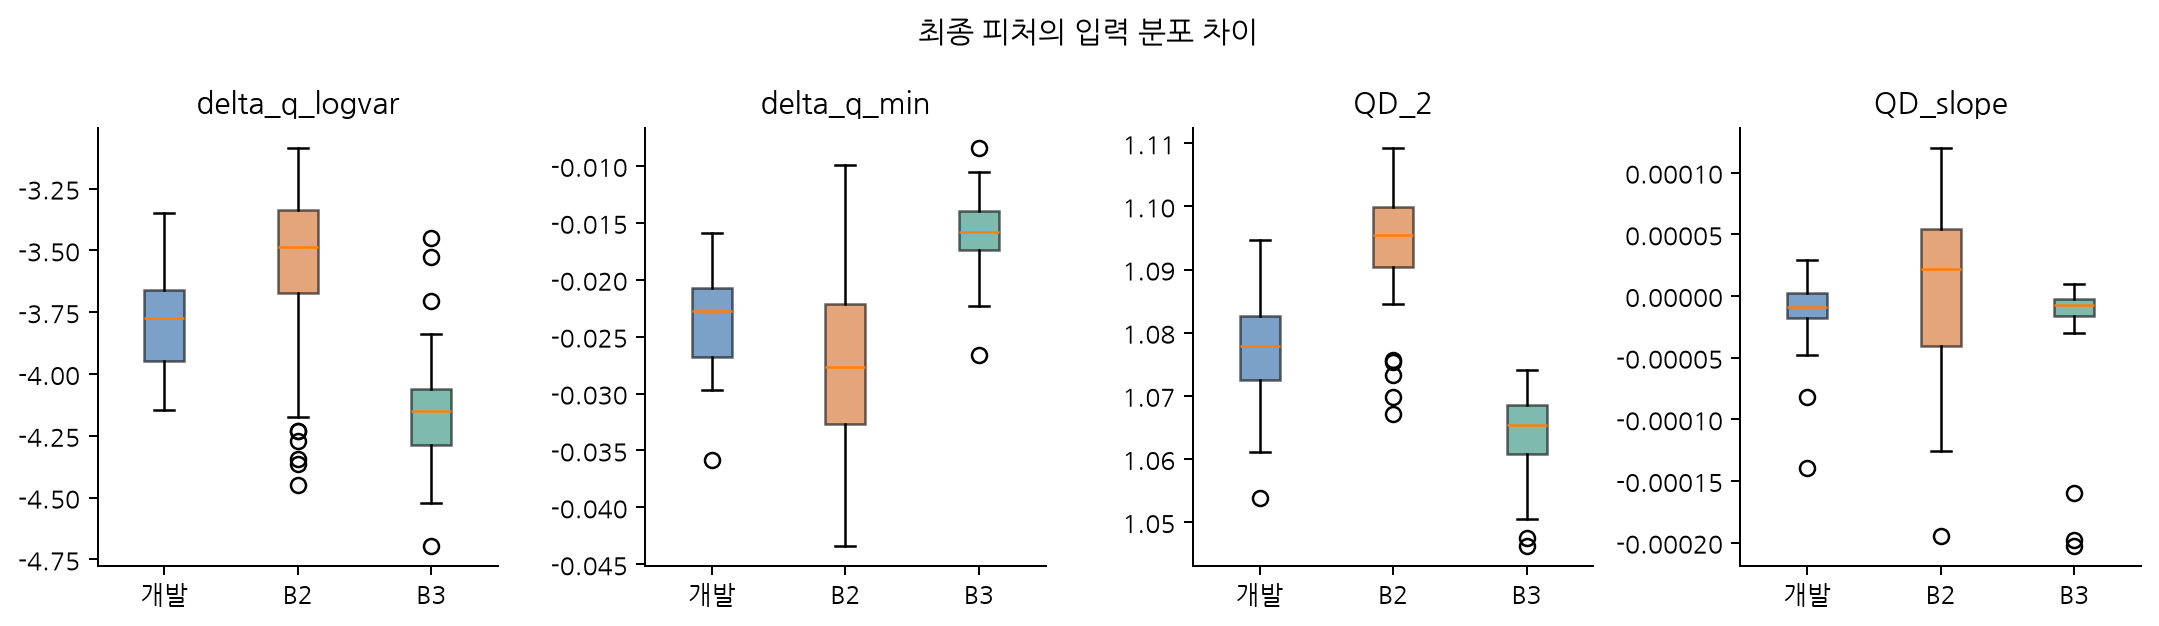

In [4]:
display(saved.groupby('batch')[cols].agg(lambda x:x.isna().sum()))
display(pd.read_csv(ROOT/'results/multicollinearity.csv').head(10))
show_plot('13_feature_drift')

## 고정 분리 검증
개발/hold-out 및 모든 CV fold 사이의 셀·정책 중복을 거부한다.

In [5]:
from src.preprocess import load_features, validate_split
f, split = load_features(ROOT)
assert validate_split(f,split)
print('개발:',len(split['development_cells']),'hold-out:',len(split['holdout_cells']))
print('정책:',split['n_development_groups'],'/',split['n_holdout_groups'])

개발: 28 hold-out: 8
정책: 15 / 5
